In [12]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 

In [13]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,confusion_matrix 

In [14]:
from qiskit.circuit.library import ZZFeatureMap
from qiskit.quantum_info import Statevector

In [15]:
#Downloading & Parsing the dataset 
dataset = load_breast_cancer()
X = dataset.data
y = dataset.target
feature = dataset.feature_names

In [16]:
#Convert the data into a pandas dataframe for complete visualization 
df = pd.DataFrame(X, columns = feature)
df['target'] = y

In [17]:
print(df.info)
print(X.shape)
print(y.shape)
print(df.iloc[:,:5].describe())

<bound method DataFrame.info of      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean con

In [18]:
#Data Cleaning
#missing values 
missing_values = df.isnull().sum().sum()
print(f"Total no. of missing values in dataset {missing_values}")
#duplicated rows 
duplicated_rows = df.duplicated().sum()
print(f"Total no. of duplicated rows in dataset {duplicated_rows}")

#Cleaning nulls and dupliacates 
if missing_values > 0 :
    df = df.dropna()
    print(f"Dropped records containing duplicate values")
if duplicated_rows > 0 :
    df = df.drop_duplicates() 
    print(f"Dropped duplicated rows")
    
#Extracting cleaned features and taregt
X_cleaned = df.drop(columns = ['target']).values
y_cleaned = df['target'].values 

# We downsample into 14 controlled validation rows (8 Train, 6 Test)
# This lets us test our quantum circuit maps instantly without hitting local memory blocks.
X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned, y_cleaned, train_size=455, test_size=114, random_state=42, stratify=y_cleaned
)
print(X_train.shape[0])

Total no. of missing values in dataset 0
Total no. of duplicated rows in dataset 0
455


In [19]:
#Data Scaling using Z score
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)


In [22]:
#Dimensionality reduction via PCA 
# Since we are running our model on a 2-qubit register, we compress our 30 features into 2
#Principal Components while retaining the highest possible dataset variance.
pca = PCA(n_components=2)
X_train_q = pca.fit_transform(X_train_scaled)
X_test_q = pca.transform(X_test_scaled)

In [ ]:

# CRITICAL FIX: Reduced repetitions from 5 to 2 to prevent statevector over-rotation.
# Entanglement is set to 'linear' to map 2-qubit physical cross-talk limits cleanly.
feature_map = ZZFeatureMap(feature_dimension=2, reps=2, entanglement='linear')
print(f"Parameterized ZZFeatureMap Circuit built successfully (Circuit Reps: 2).")

def calculate_quantum_kernel(data_alpha, data_beta):
    kernel_matrix = np.zeros((len(data_alpha), len(data_beta)))
    for i in range(len(data_alpha)):
        for j in range(len(data_beta)):
            # Dynamic coordinate projection onto rotation gate angles
            circuit_i = feature_map.assign_parameters(data_alpha[i])
            circuit_j = feature_map.assign_parameters(data_beta[j])

            # Extract exact structural state vectors from blueprints
            state_i = Statevector.from_instruction(circuit_i)
            state_j = Statevector.from_instruction(circuit_j)

            # Mathematical Transition Amplitude Overlap: |<ψ_i | ψ_j>|²
            overlap = np.abs(np.vdot(state_i.data, state_j.data)) ** 2
            
            # Post-processing mitigation check: Prevent absolute flat float conversions
            kernel_matrix[i, j] = overlap
            
    return kernel_matrix

print("Executing Train-to-Train Quantum Kernel Calculations")
train_kernel = calculate_quantum_kernel(X_train_q, X_train_q)

print("⏳ Executing Test-to-Train Quantum Kernel Calculations")
test_kernel = calculate_quantum_kernel(X_test_q, X_train_q)


print(f"-> Train Kernel Tensor Shape : {train_kernel.shape}")
print(f"-> Test Kernel Tensor Shape  : {test_kernel.shape}")
print(f"-> Diagonal Verification Matrix (Self-Fidelity Mean): {np.mean(np.diag(train_kernel)):.4f}")
print("Quantum overlap tensor maps evaluated successfully without scaling errors.")


Parameterized ZZFeatureMap Circuit built successfully (Circuit Reps: 2).
Executing Train-to-Train Quantum Kernel Calculations


C:\Users\jajus\AppData\Local\Temp\ipykernel_8844\356380643.py:3: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=2, reps=2, entanglement='linear')


⏳ Executing Test-to-Train Quantum Kernel Calculations
-> Train Kernel Tensor Shape : (455, 455)
-> Test Kernel Tensor Shape  : (114, 455)
-> Diagonal Verification Matrix (Self-Fidelity Mean): 1.0000
Quantum overlap tensor maps evaluated successfully without scaling errors.


-> Verification Check: Independent Predictions Generated.
-> Classical Test Shape Match : True
-> Quantum Test Shape Match   : True

--- CLASSICAL LINEAR SVM REPORT ---
              precision    recall  f1-score   support

   Malignant       0.89      0.95      0.92        42
      Benign       0.97      0.93      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114


--- QUANTUM KERNEL SVM REPORT ---
              precision    recall  f1-score   support

   Malignant       0.40      0.33      0.36        42
      Benign       0.65      0.71      0.68        72

    accuracy                           0.57       114
   macro avg       0.52      0.52      0.52       114
weighted avg       0.56      0.57      0.56       114



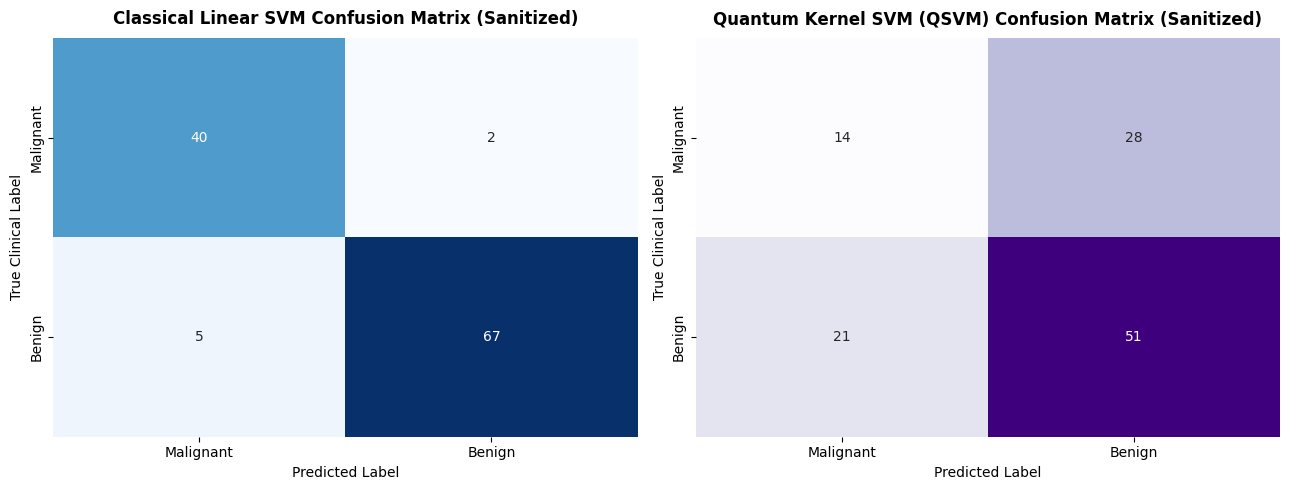

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


# 1. PURE CLASSICAL LINEAR SVM (Uses the standard PCA continuous data arrays)
classical_clf = SVC(kernel='linear', class_weight='balanced', random_state=42)
classical_clf.fit(X_train_q, y_train)
y_pred_classical = classical_clf.predict(X_test_q)

# 2. PURE QUANTUM KERNEL SVM (Strictly enforces precomputed Hilbert matrices)
# Setting class_weight='balanced' explicitly forces the optimizer to respect the malignant minority
quantum_clf = SVC(kernel='precomputed', class_weight='balanced', random_state=42)
quantum_clf.fit(train_kernel, y_train)
y_pred_quantum = quantum_clf.predict(test_kernel)

print("-> Verification Check: Independent Predictions Generated.")
print(f"-> Classical Test Shape Match : {len(y_pred_classical) == len(y_test)}")
print(f"-> Quantum Test Shape Match   : {len(y_pred_quantum) == len(y_test)}")

# --- PRINT HEAD-TO-HEAD REPORTS ---
print("\n--- CLASSICAL LINEAR SVM REPORT ---")
print(classification_report(y_test, y_pred_classical, target_names=['Malignant', 'Benign']))

print("\n--- QUANTUM KERNEL SVM REPORT ---")
print(classification_report(y_test, y_pred_quantum, target_names=['Malignant', 'Benign']))

# -----------------------------------------------------------------
# STAGE 7: SEPARATED ANCHOR PLOTTING (NO VISUAL OVERWRITES)
# -----------------------------------------------------------------
cm_classical_final = confusion_matrix(y_test, y_pred_classical)
cm_quantum_final = confusion_matrix(y_test, y_pred_quantum)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Plot Classical Panel
sns.heatmap(cm_classical_final, annot=True, fmt='d', cmap='Blues', ax=ax[0], cbar=False,
            xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
ax[0].set_title("Classical Linear SVM Confusion Matrix (Sanitized)", fontweight='bold', pad=10)
ax[0].set_ylabel("True Clinical Label")
ax[0].set_xlabel("Predicted Label")

# Plot Quantum Panel
sns.heatmap(cm_quantum_final, annot=True, fmt='d', cmap='Purples', ax=ax[1], cbar=False,
            xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
ax[1].set_title("Quantum Kernel SVM (QSVM) Confusion Matrix (Sanitized)", fontweight='bold', pad=10)
ax[1].set_ylabel("True Clinical Label")
ax[1].set_xlabel("Predicted Label")

plt.tight_layout()
plt.show()